# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [1]:
import os
import shutil
import random
from icrawler.builtin import GoogleImageCrawler, BingImageCrawler

### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

In [2]:
def download_images(keyword, folder, n_total=100):
    os.makedirs(folder, exist_ok=True)
    downloaded = len(os.listdir(folder))
    remaining = n_total - downloaded

    while downloaded < n_total:
        crawler = GoogleImageCrawler(storage={'root_dir': folder})
        crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
        downloaded = len(os.listdir(folder))
        remaining = n_total - downloaded
        print(f"Downloaded {downloaded}/{n_total}")

    print("Download complete!")

In [3]:
search_terms = {
    "vader": "darth vader", # nome da classe: termo que será usado na busca
    "Luke": "luke skywalker",
    "Yoda": "yoda",
    "Leia": "princess leia",
}

for label, term in search_terms.items():
    download_images(term, f"data/star_wars/{label}", n_total=100)

Download complete!
Download complete!
Download complete!
Download complete!


### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

In [4]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

In [5]:
split_train_val("D:\\downloads\\reforço\\data\\star_wars")

Leia: 80 train, 20 val
Luke: 80 train, 20 val
Luke: 80 train, 20 val
vader: 80 train, 20 val
vader: 80 train, 20 val
Yoda: 80 train, 20 val
Yoda: 80 train, 20 val


## Dataset

Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
    


In [7]:


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Dataset personalizado para carregar as imagens do Star Wars
class StarWarsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['Leia', 'Luke', 'vader', 'Yoda']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        self.images = []
        self.labels = []
        
        for class_name in self.classes:
            class_path = os.path.join(root_dir, class_name)
            if os.path.exists(class_path):
                for img_name in os.listdir(class_path):
                    img_path = os.path.join(class_path, img_name)
                    if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(img_path)
                        self.labels.append(self.class_to_idx[class_name])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        #algumas imagens davam erro e quebrava o codigo
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), (0, 0, 0))
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# data augmentation para treinho
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))  # ImageNet stats
])

# validação, sem augmentation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

train_dataset = StarWarsDataset('D:\\downloads\\reforço\\data\\star_wars_split\\train', transform=train_transform)
val_dataset = StarWarsDataset('D:\\downloads\\reforço\\data\\star_wars_split\\val', transform=val_transform)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

classes = ['Leia', 'Luke', 'Vader', 'Yoda']
print(f'Dataset carregado: {len(train_dataset)} imagens de treino, {len(val_dataset)} imagens de validação')

Using device: cpu
Dataset carregado: 320 imagens de treino, 80 imagens de validação


## Definição do Modelo

Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado. Teste diversas arquiteturas diferentes e verifique qual delas tem melhor desempenho em validação.

In [8]:
class StarWarsCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(StarWarsCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((7, 7))
        )
        #classificar
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # extrai feature
        x = self.features(x)
        
        # achata saida
        x = x.view(x.size(0), -1)
        
        # classificar
        x = self.classifier(x)
        
        return x
        return x

model = StarWarsCNN(num_classes=4).to(device)

# entrada aleatória
x = torch.randn(1, 3, 224, 224).to(device)
out = model(x)
print(f'Número de parâmetros: {sum(p.numel() for p in model.parameters()):,}')

Número de parâmetros: 6,878,596


## Treinamento

Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

In [9]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# scheduler para reduzir a learning rate
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # train
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # validation
    model.eval()
    running_loss_val = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            
            running_loss_val += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = running_loss_val / len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    # learning rate
    scheduler.step()
    
    print(f'Epoch [{epoch + 1}/{num_epochs}] -> Train Loss: {train_loss:.3f}, Train Acc: {train_accuracy:.2f}% | Val Loss: {val_loss:.3f}, Val Acc: {val_accuracy:.2f}%')

C:\Users\jomac\AppData\Roaming\Python\Python312\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/20] -> Train Loss: 1.440, Train Acc: 39.06% | Val Loss: 1.059, Val Acc: 52.50%
Epoch [2/20] -> Train Loss: 1.137, Train Acc: 51.88% | Val Loss: 0.852, Val Acc: 65.00%
Epoch [2/20] -> Train Loss: 1.137, Train Acc: 51.88% | Val Loss: 0.852, Val Acc: 65.00%
Epoch [3/20] -> Train Loss: 1.035, Train Acc: 57.19% | Val Loss: 0.922, Val Acc: 62.50%
Epoch [3/20] -> Train Loss: 1.035, Train Acc: 57.19% | Val Loss: 0.922, Val Acc: 62.50%
Epoch [4/20] -> Train Loss: 1.008, Train Acc: 59.06% | Val Loss: 0.918, Val Acc: 61.25%
Epoch [4/20] -> Train Loss: 1.008, Train Acc: 59.06% | Val Loss: 0.918, Val Acc: 61.25%
Epoch [5/20] -> Train Loss: 0.951, Train Acc: 62.19% | Val Loss: 0.887, Val Acc: 66.25%
Epoch [5/20] -> Train Loss: 0.951, Train Acc: 62.19% | Val Loss: 0.887, Val Acc: 66.25%
Epoch [6/20] -> Train Loss: 0.847, Train Acc: 64.06% | Val Loss: 0.989, Val Acc: 63.75%
Epoch [6/20] -> Train Loss: 0.847, Train Acc: 64.06% | Val Loss: 0.989, Val Acc: 63.75%
Epoch [7/20] -> Train Loss: 0.79

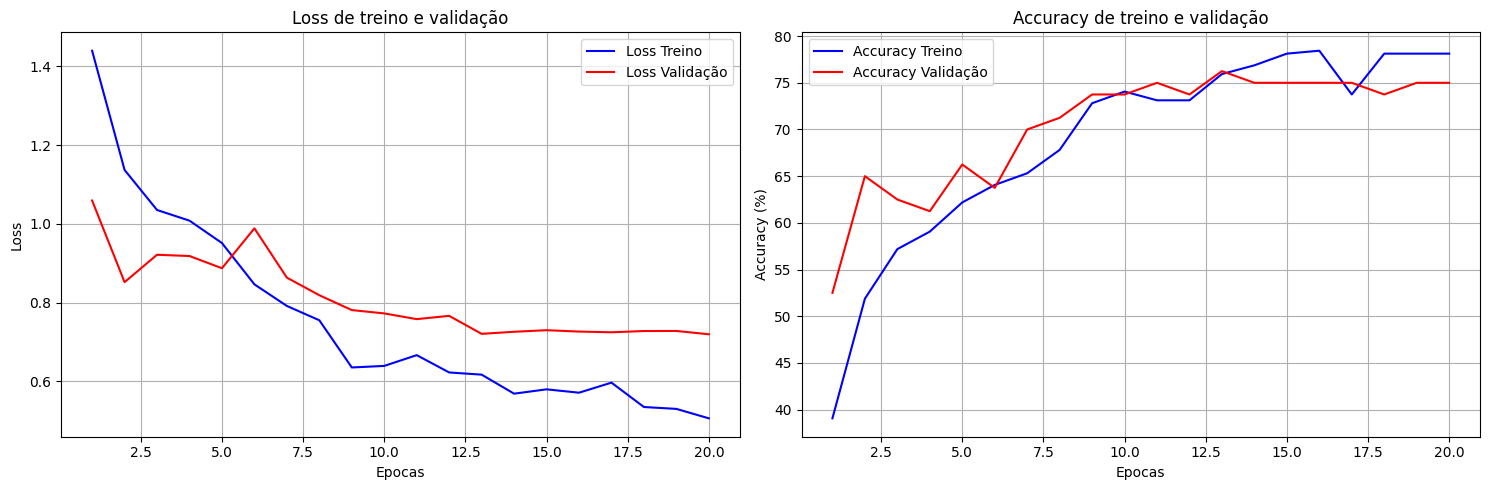

In [13]:
# 
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'blue', label='Loss Treino')
plt.plot(range(1, num_epochs + 1), val_losses, 'red', label='Loss Validação')
plt.xlabel('Epocas')
plt.ylabel('Loss')
plt.title('Loss de treino e validação')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, 'blue', label='Accuracy Treino')
plt.plot(range(1, num_epochs + 1), val_accuracies, 'red', label='Accuracy Validação')
plt.xlabel('Epocas')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy de treino e validação')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Inferência

Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

C:\Users\jomac\AppData\Roaming\Python\Python312\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Acurácia final no conjunto de validação: 75.00%

Relatório de Classificação:
              precision    recall  f1-score   support

        Leia       0.71      0.75      0.73        20
        Luke       0.60      0.30      0.40        20
       Vader       0.79      0.95      0.86        20
        Yoda       0.80      1.00      0.89        20

    accuracy                           0.75        80
   macro avg       0.73      0.75      0.72        80
weighted avg       0.73      0.75      0.72        80



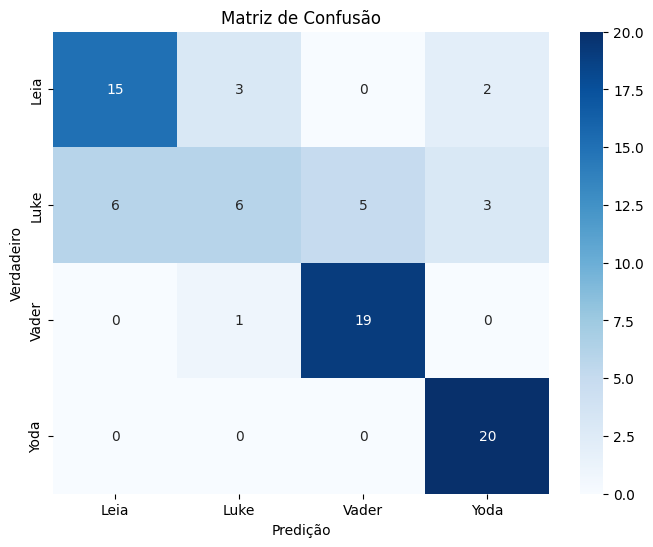

In [11]:
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * np.mean(np.array(all_predictions) == np.array(all_labels))
print(f'Acurácia final no conjunto de validação: {accuracy:.2f}%')

print("\nRelatório de Classificação:")
print(classification_report(all_labels, all_predictions, target_names=classes))

cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão')
plt.xlabel('Predição')
plt.ylabel('Verdadeiro')
plt.show()

In [14]:
for i in [['darth_vader_div_lucasfilm.jpg',"Vade"], ['Luke.jpg','Luke'], ['leia.jpeg',"Leia"], ['luke1.jpg',"Luke"]]:
    image = Image.open(i[0]).convert('RGB')
    image_tensor = val_transform(image).unsqueeze(0).to(device)

    # predição
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        _, predicted = torch.max(output, 1)
        
    predicted_class = classes[predicted.item()]
    confidence = probabilities[predicted.item()].item() * 100
    print("Prediction for image:", i[0])
    print("Predicated: " + str(predicted_class) + " | Actual: " + i[1])
    print("cofiança:", confidence )
    print("################")

    

Prediction for image: darth_vader_div_lucasfilm.jpg
Predicated: Vader | Actual: Vade
cofiança: 85.6624186038971
################
Prediction for image: Luke.jpg
Predicated: Yoda | Actual: Luke
cofiança: 54.32270169258118
################
Prediction for image: leia.jpeg
Predicated: Leia | Actual: Leia
cofiança: 61.73977255821228
################
Prediction for image: luke1.jpg
Predicated: Luke | Actual: Luke
cofiança: 59.466177225112915
################
